<a href="https://colab.research.google.com/github/YaramalaSaiSandeepreddy/Insurance-claim-approvel/blob/main/Insurance_claim_approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
import pandas as pd

data = pd.read_csv("insurance_claim_approval.csv")

data.head()


,Customer_ID,Age,Gender,Employment_Status,Annual_Income,Dependents,Policy_Type,Policy_Duration,Premium_Amount,Coverage_Amount,Claim_Amount,Past_Claims,Time_Since_Last_Claim,Documents_Submitted,Fraud_Risk,Claim_Approval
0,1,56,Male,Employed,178721,3,Health,10,16888,27552,33684,6,118,7,Low,0
1,2,69,Female,Retired,32402,4,Auto,13,17035,321882,67808,2,56,3,Low,1
2,3,46,Female,Unemployed,122880,3,Life,18,12944,26438,59474,1,40,3,Low,0
3,4,32,Female,Self-Employed,139764,0,Auto,19,12021,278921,91288,1,26,2,Low,0
4,5,60,Male,Retired,160288,2,Health,17,3577,106794,13416,9,14,9,High,0


In [ ]:
# Claim ratio (Claim amount relative to income)
data["Claim_Income_Ratio"] = data["Claim_Amount"] / (data["Annual_Income"] + 1)

# Risk score based on fraud risk + previous claims
data["Risk_Score"] = data["Past_Claims"] * 2

# Policy duration category
data["Long_Policy"] = (data["Policy_Duration"] > 5).astype(int)

# High claim flag
data["High_Claim"] = (data["Claim_Amount"] > data["Claim_Amount"].mean()).astype(int)

# Payment reliability
data["Reliable_Payer"] = (data["Premium_Amount"] == 1).astype(int)

data.head()

,Customer_ID,Age,Gender,Employment_Status,Annual_Income,Dependents,Policy_Type,Policy_Duration,Premium_Amount,Coverage_Amount,...,Past_Claims,Time_Since_Last_Claim,Documents_Submitted,Fraud_Risk,Claim_Approval,Claim_Income_Ratio,Risk_Score,Long_Policy,High_Claim,Reliable_Payer
0,1,56,Male,Employed,178721,3,Health,10,16888,27552,...,6,118,7,Low,0,0.188471,12,1,0,0
1,2,69,Female,Retired,32402,4,Auto,13,17035,321882,...,2,56,3,Low,1,2.092646,4,1,1,0
2,3,46,Female,Unemployed,122880,3,Life,18,12944,26438,...,1,40,3,Low,0,0.483997,2,1,1,0
3,4,32,Female,Self-Employed,139764,0,Auto,19,12021,278921,...,1,26,2,Low,0,0.653154,2,1,1,0
4,5,60,Male,Retired,160288,2,Health,17,3577,106794,...,9,14,9,High,0,0.083699,18,1,0,0


In [ ]:
data = data.drop("Customer_ID", axis=1)


In [ ]:
categorical_cols = ["Gender", "Employment_Status", "Policy_Type", "Fraud_Risk"]

data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)


In [ ]:
X = data.drop("Claim_Approval", axis=1)
y = data["Claim_Approval"]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score

# Predictions
y_pred = model.predict(X_test)

# Probabilities (for ROC AUC)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9925
Precision: 0.9891808346213292
Recall: 0.9992193598750976
F1 Score: 0.9941747572815534
ROC AUC: 0.9999343133135513

Confusion Matrix:
 [[ 705   14]
 [   1 1280]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       719
           1       0.99      1.00      0.99      1281

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [ ]:
y_pred = model.predict(X_test)


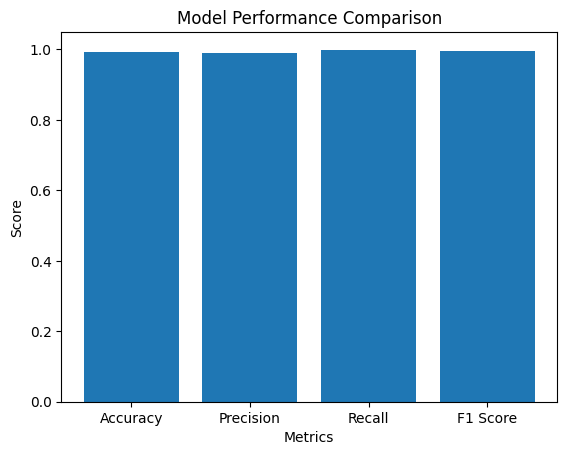

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [accuracy, precision, recall, f1]

# Plot comparison
plt.figure()
plt.bar(metrics, values)
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.show()
